# 👁️ Eye Disease Detection - Cataract vs Normal
### Using MobileNetV2 + Transfer Learning
---

## Cell 1 - استيراد المكتبات

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

✅ Libraries imported successfully!
TensorFlow version: 2.20.0


## Cell 2 - إعداد المسارات والإعدادات

In [2]:
TRAIN_DIR = 'archive/train'   # مسار فولدر التدريب
TEST_DIR  = 'archive/test'    # مسار فولدر الاختبار

# إعدادات الموديل
IMG_SIZE    = 224       # حجم الصورة (MobileNetV2 بيحتاج 224x224)
BATCH_SIZE  = 32        # عدد الصور في كل batch
EPOCHS      = 30        # عدد مرات التدريب
NUM_CLASSES = 3        # عدد الكلاسات (cataract - normal)
LEARNING_RATE = 0.0001  # معدل التعلم

# التحقق من الداتا
for split in ['train', 'test']:
    path = TRAIN_DIR if split == 'train' else TEST_DIR
    print(f'\n📂 {split.upper()}:')
    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            print(f'   {cls}: {count} صورة')

print('\n✅ Settings configured!')


📂 TRAIN:
   .ipynb_checkpoints: 0 صورة
   cataract: 285 صورة
   normal: 344 صورة

📂 TEST:
   .ipynb_checkpoints: 0 صورة
   cataract: 45 صورة
   normal: 55 صورة

✅ Settings configured!


## Cell 2.5 - تنظيف الداتا (Data Cleaning)

In [ ]:
from PIL import Image
import hashlib

# ======================================
# إعدادات الـ Cleaning
# ======================================
MIN_SIZE         = 50    # أقل حجم مقبول للصورة (بيكسل)
MIN_FILE_SIZE    = 1000  # أقل حجم ملف (بايت)
BLUR_THRESHOLD   = 50    # حد الضبابية
DARK_THRESHOLD   = 20    # حد الإضاءة المظلمة
BRIGHT_THRESHOLD = 240   # حد السطوع الزيادة
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

def get_image_hash(fpath):
    with open(fpath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

def check_blur(fpath):
    img = cv2.imread(fpath)
    if img is None: return 0
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def check_brightness(fpath):
    img = cv2.imread(fpath)
    if img is None: return 0
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).mean()

def clean_dataset(base_dir, remove_bad=False):
    print(f'🔍 فحص: {base_dir}')
    print('=' * 60)
    stats = dict(total=0, corrupted=0, duplicates=0,
                 too_small=0, blurry=0, dark=0, bright=0,
                 wrong_ext=0, removed=0)
    seen_hashes = {}
    bad_files = []

    for cls in sorted(os.listdir(base_dir)):
        cls_path = os.path.join(base_dir, cls)
        if not os.path.isdir(cls_path): continue
        print(f'\n📂 كلاس: {cls}')
        cls_bad = 0
        cls_total = 0

        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            if not os.path.isfile(fpath): continue
            stats['total'] += 1
            cls_total += 1
            reason = None
            ext = os.path.splitext(fname)[1].lower()

            if ext not in VALID_EXTENSIONS:
                reason = f'امتداد خاطئ ({ext})'
                stats['wrong_ext'] += 1
            elif os.path.getsize(fpath) < MIN_FILE_SIZE:
                reason = f'ملف صغير جداً'
                stats['too_small'] += 1
            else:
                try:
                    img = Image.open(fpath)
                    img.verify()
                    img = Image.open(fpath)
                    w, h = img.size
                    if w < MIN_SIZE or h < MIN_SIZE:
                        reason = f'أبعاد صغيرة ({w}x{h})'
                        stats['too_small'] += 1
                    else:
                        img_hash = get_image_hash(fpath)
                        if img_hash in seen_hashes:
                            reason = f'مكررة'
                            stats['duplicates'] += 1
                        else:
                            seen_hashes[img_hash] = fname
                            blur = check_blur(fpath)
                            if blur < BLUR_THRESHOLD:
                                reason = f'ضبابية (score={blur:.1f})'
                                stats['blurry'] += 1
                            else:
                                br = check_brightness(fpath)
                                if br < DARK_THRESHOLD:
                                    reason = f'مظلمة جداً ({br:.1f})'
                                    stats['dark'] += 1
                                elif br > BRIGHT_THRESHOLD:
                                    reason = f'فاتحة جداً ({br:.1f})'
                                    stats['bright'] += 1
                except Exception as e:
                    reason = f'تالفة'
                    stats['corrupted'] += 1

            if reason:
                cls_bad += 1
                bad_files.append((fpath, reason))
                print(f'   ⚠️  {fname}: {reason}')
                if remove_bad:
                    os.remove(fpath)
                    stats['removed'] += 1

        icon = '✅' if cls_bad == 0 else '⚠️'
        print(f'   {icon} الإجمالي: {cls_total} | مشاكل: {cls_bad}')

    print('\n' + '=' * 60)
    print('📊 تقرير التنظيف:')
    print('=' * 60)
    print(f'   إجمالي الصور   : {stats["total"]}')
    print(f'   صور تالفة      : {stats["corrupted"]}')
    print(f'   صور مكررة      : {stats["duplicates"]}')
    print(f'   صور صغيرة      : {stats["too_small"]}')
    print(f'   صور ضبابية     : {stats["blurry"]}')
    print(f'   صور مظلمة      : {stats["dark"]}')
    print(f'   صور فاتحة      : {stats["bright"]}')
    print(f'   امتدادات خاطئة : {stats["wrong_ext"]}')
    print(f'\n   ⚠️  إجمالي المشاكل: {len(bad_files)}')
    if remove_bad:
        print(f'   🗑️  تم حذف: {stats["removed"]} صورة')
    else:
        print('\n💡 لحذف الصور السيئة:')
        print('   clean_dataset(TRAIN_DIR, remove_bad=True)')
        print('   clean_dataset(TEST_DIR,  remove_bad=True)')
    print('\n✅ انتهى الفحص!')
    return bad_files


# فحص بدون حذف الأول
print('📂 فحص TRAIN:')
bad_train = clean_dataset(TRAIN_DIR, remove_bad=False)
print('\n📂 فحص TEST:')
bad_test = clean_dataset(TEST_DIR, remove_bad=False)

📂 فحص TRAIN:
🔍 فحص: archive/train

📂 كلاس: .ipynb_checkpoints
   ✅ الإجمالي: 0 | مشاكل: 0

📂 كلاس: cataract
   ⚠️  5621050615_85cc77061a_o.jpg: ضبابية (score=42.2)
   ⚠️ الإجمالي: 284 | مشاكل: 1

📂 كلاس: normal


In [6]:
import shutil

confirm = input('هل تريد نقل الصور السيئة؟ اكتب YES للتأكيد: ')
if confirm.strip().upper() == 'YES':
    print('\n📦 جاري نقل الصور السيئة...')
    
    for fpath, reason in bad_train + bad_test:
        try:
            # إنشاء فولدر bad_images
            bad_dir = os.path.join(os.path.dirname(fpath), '..', '..', 'bad_images')
            os.makedirs(bad_dir, exist_ok=True)
            shutil.move(fpath, os.path.join(bad_dir, os.path.basename(fpath)))
            print(f'   📦 تم نقل: {os.path.basename(fpath)}')
        except Exception as e:
            print(f'   ❌ مش قادر ينقل {os.path.basename(fpath)}: {e}')
    
    print('\n✅ تم! الصور السيئة اتنقلت لفولدر bad_images 🎉')
else:
    print('❌ تم الإلغاء.')

هل تريد نقل الصور السيئة؟ اكتب YES للتأكيد:  ىخ


❌ تم الإلغاء.


## Cell 3 - تحضير الداتا والـ Augmentation

In [10]:
# Data Augmentation للـ Training (لزيادة تنوع البيانات)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # تطبيع الصور
    rotation_range=20,        # تدوير عشوائي
    width_shift_range=0.1,    # إزاحة أفقية
    height_shift_range=0.1,   # إزاحة رأسية
    shear_range=0.1,          # قص
    zoom_range=0.1,           # تكبير/تصغير
    horizontal_flip=True,     # قلب أفقي
    brightness_range=[0.8, 1.2],  # تغيير السطوع
    fill_mode='nearest'
)

# للـ Test بس التطبيع من غير Augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# تحميل الداتا
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# طباعة معلومات الكلاسات
CLASS_NAMES = list(train_generator.class_indices.keys())
print(f'\n📌 الكلاسات: {CLASS_NAMES}')
print(f'📌 Indices: {train_generator.class_indices}')
print(f'\n✅ Data loaded successfully!')
print(f'   Training samples  : {train_generator.samples}')
print(f'   Testing samples   : {test_generator.samples}')

Found 628 images belonging to 3 classes.
Found 100 images belonging to 3 classes.

📌 الكلاسات: ['.ipynb_checkpoints', 'cataract', 'normal']
📌 Indices: {'.ipynb_checkpoints': 0, 'cataract': 1, 'normal': 2}

✅ Data loaded successfully!
   Training samples  : 628
   Testing samples   : 100


## Cell 4 - عرض عينة من الداتا

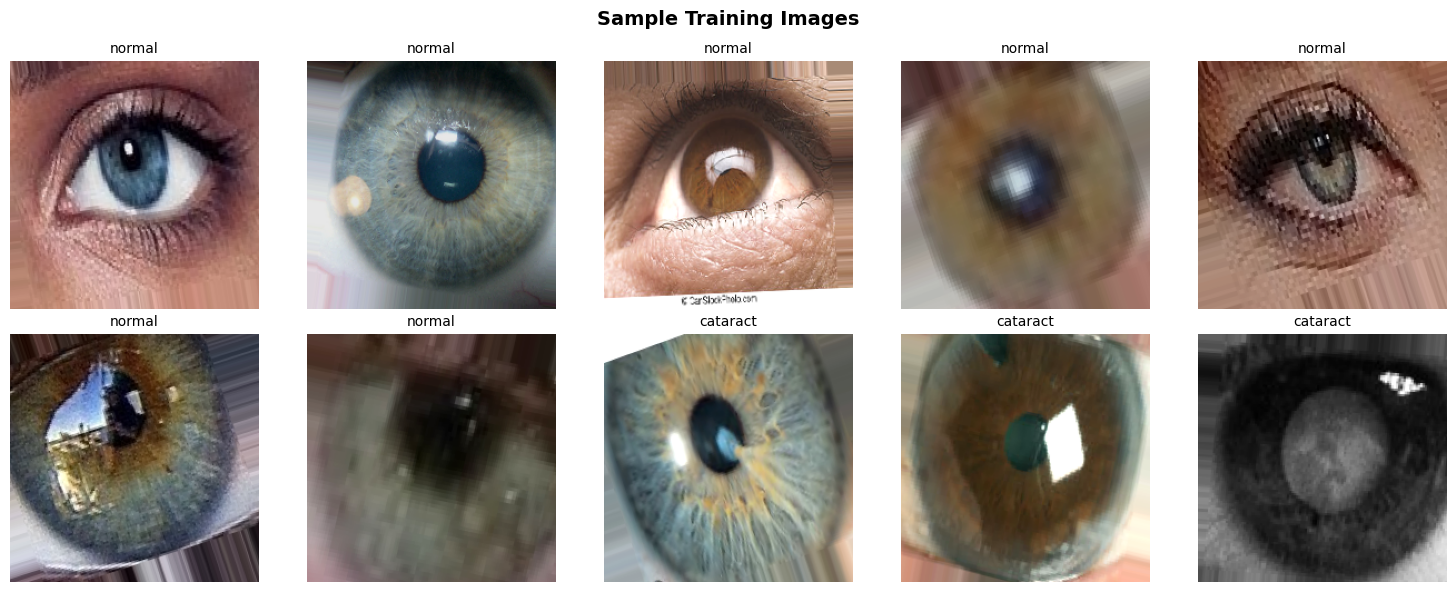

✅ Sample images displayed!


In [11]:
# عرض 10 صور من الداتا
images, labels = next(train_generator)

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i])
    label_idx = np.argmax(labels[i])
    plt.title(CLASS_NAMES[label_idx], fontsize=10)
    plt.axis('off')

plt.suptitle('Sample Training Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ Sample images displayed!')

## Cell 5 - بناء الموديل بـ MobileNetV2

In [12]:
def build_model(num_classes, img_size, learning_rate):
    """
    بناء موديل Transfer Learning باستخدام MobileNetV2
    """
    # تحميل MobileNetV2 بدون الـ top layers
    base_model = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'  # أوزان مدربة على ImageNet
    )
    
    # تجميد الـ base model في البداية
    base_model.trainable = False
    
    # إضافة الـ custom layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=output)
    
    # compile الموديل
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model, base_model

# بناء الموديل
model, base_model = build_model(NUM_CLASSES, IMG_SIZE, LEARNING_RATE)

print('✅ Model built successfully!')
print(f'   Total parameters    : {model.count_params():,}')
print(f'   Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')
model.summary()

✅ Model built successfully!
   Total parameters    : 2,624,323
   Trainable parameters: 363,779


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,624,323 (10.01 MB)

 Trainable params: 363,779 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## Cell 6 - إعداد الـ Callbacks

In [13]:
# Callbacks لتحسين التدريب
callbacks = [
    # وقف التدريب لو الموديل مش بيتحسن
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    # حفظ أحسن موديل
    ModelCheckpoint(
        'best_eye_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # تقليل الـ Learning Rate لو الموديل وقف
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print('✅ Callbacks configured!')

✅ Callbacks configured!


## Cell 7 - المرحلة الأولى من التدريب (Feature Extraction)

In [14]:
print('🚀 Phase 1: Training custom layers only...')
print('=' * 50)

history_phase1 = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Phase 1 complete!')
best_val_acc = max(history_phase1.history['val_accuracy'])
print(f'   Best Validation Accuracy: {best_val_acc*100:.2f}%')

🚀 Phase 1: Training custom layers only...
Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1690 - loss: 2.4075    
Epoch 1: val_accuracy improved from None to 0.45000, saving model to best_eye_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.2484 - loss: 2.0384 - val_accuracy: 0.4500 - val_loss: 1.0102 - learning_rate: 1.0000e-04
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5015 - loss: 1.3015    
Epoch 2: val_accuracy improved from 0.45000 to 0.77000, saving model to best_eye_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.5334 - loss: 1.1186 - val_accuracy: 0.7700 - val_loss: 0.6126 - learning_rate: 1.0000e-04
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6235 - loss: 0.8858    
Epoch 3: val_accuracy improved from 0.77000 to 0.88000, saving model to best_eye_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.6736 - loss: 0.7843 - val_accuracy: 0.8800 - val_loss: 0.4327 - learning_rate: 1.0000e-04
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7599 - loss: 0.5884    
Epoch 4: val_accuracy improved from 0.88000 to 0.89000, saving model to best_eye_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.7548 - loss: 0.5931 - val_accuracy: 0.8900 - val_loss: 0.3531 - learning_rate: 1.0000e-04
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8112 - loss: 0.5552    
Epoch 5: val_accuracy did not improve from 0.89000
20/20 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.8025 - loss: 0.5394 - val_accuracy: 0.8900 - val_loss: 0.2995 - learning_rate: 1.0000e-04
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8086 - loss: 0.5112    
Epoch 6: val_accuracy did not improve from 0.89000
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8121 - loss: 0.4806 - val_accuracy: 0.8900 - val_loss: 0.2688 - learning_rate: 1.0000e-04
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7887 - loss: 0.5059 
Epoch 7: val_accuracy did not improve from 0.89000
20/20 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.8169 - loss: 0.4384 - val_accuracy: 0.8900 - val_loss: 0.2416 - learning_rate: 1.0000e-04
Epoch 8/15
20/20 

20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.8328 - loss: 0.4214 - val_accuracy: 0.9000 - val_loss: 0.2329 - learning_rate: 1.0000e-04
Epoch 9/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8506 - loss: 0.3925    
Epoch 9: val_accuracy improved from 0.90000 to 0.91000, saving model to best_eye_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.8615 - loss: 0.3861 - val_accuracy: 0.9100 - val_loss: 0.2179 - learning_rate: 1.0000e-04
Epoch 10/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8619 - loss: 0.3855 
Epoch 10: val_accuracy did not improve from 0.91000
20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.8567 - loss: 0.3560 - val_accuracy: 0.9100 - val_loss: 0.2085 - learning_rate: 1.0000e-04
Epoch 11/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8659 - loss: 0.3631   
Epoch 11: val_accuracy did not improve from 0.91000
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8583 - loss: 0.3914 - val_accuracy: 0.9100 - val_loss: 0.2020 - learning_rate: 1.0000e-04
Epoch 12/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8272 - loss: 0.4346    
Epoch 12: val_accuracy improved from 0.91000 to 0.93000, saving model to best_eye_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8487 - loss: 0.3926 - val_accuracy: 0.9300 - val_loss: 0.1977 - learning_rate: 1.0000e-04
Epoch 13/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8897 - loss: 0.3270    
Epoch 13: val_accuracy did not improve from 0.93000
20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.8917 - loss: 0.3154 - val_accuracy: 0.9200 - val_loss: 0.1910 - learning_rate: 1.0000e-04
Epoch 14/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8609 - loss: 0.3295    
Epoch 14: val_accuracy did not improve from 0.93000
20/20 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.8710 - loss: 0.3237 - val_accuracy: 0.9300 - val_loss: 0.1848 - learning_rate: 1.0000e-04
Epoch 15/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9124 - loss: 0.2361    
Epoch 15: val_accuracy did not improve from 0.93000
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9045 - loss: 0.2579 - val_accuracy: 0.9300 - val_loss: 0.1874 - learning_rate: 1.0000e-04
Restorin

## Cell 8 - المرحلة التانية (Fine-Tuning)

In [15]:
print('🔧 Phase 2: Fine-tuning...')
print('=' * 50)

# فتح آخر 30 layer في الـ base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# إعادة compile بـ learning rate أصغر
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE / 10),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Phase 2 complete!')
best_val_acc = max(history_phase2.history['val_accuracy'])
print(f'   Best Validation Accuracy: {best_val_acc*100:.2f}%')

🔧 Phase 2: Fine-tuning...
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8145 - loss: 0.4848    
Epoch 1: val_accuracy did not improve from 0.93000
20/20 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.7930 - loss: 0.4915 - val_accuracy: 0.9100 - val_loss: 0.1887 - learning_rate: 1.0000e-05
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7840 - loss: 0.5400    
Epoch 2: val_accuracy did not improve from 0.93000
20/20 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.7978 - loss: 0.4858 - val_accuracy: 0.9100 - val_loss: 0.1852 - learning_rate: 1.0000e-05
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8174 - loss: 0.4850    
Epoch 3: val_accuracy did not improve from 0.93000

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.8185 - loss: 0.4624 - val_accuracy: 0.9100 - val_loss: 0.1855 - learning_rate: 1.0000e-05
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - ac

## Cell 9 - رسم منحنيات التدريب

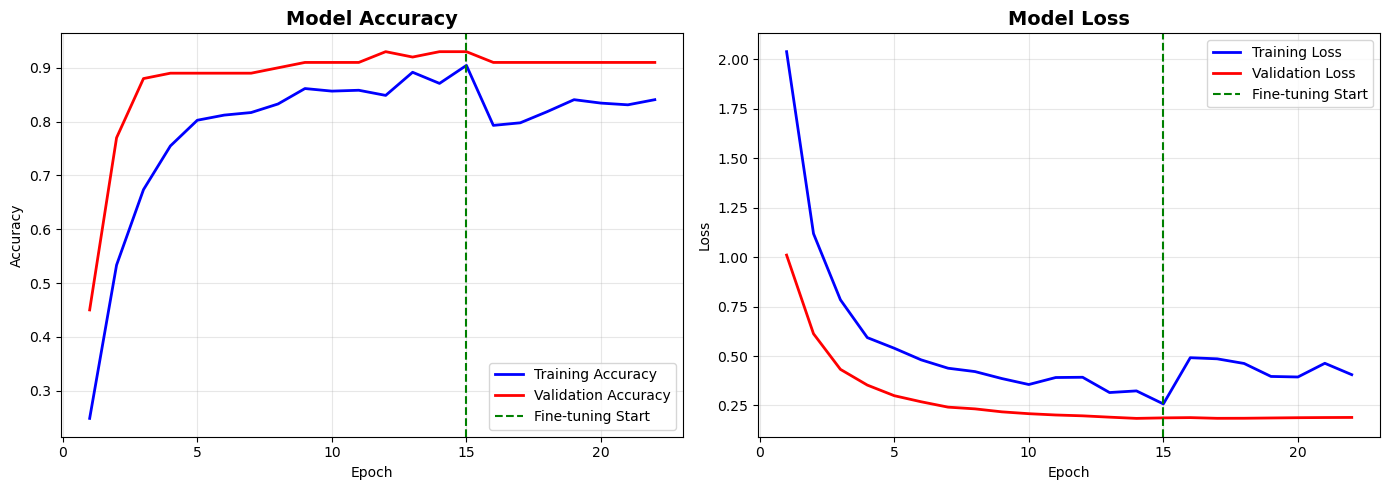

✅ Training curves saved!


In [16]:
def plot_history(h1, h2):
    # دمج الـ history
    acc     = h1.history['accuracy']     + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss    = h1.history['loss']         + h2.history['loss']
    val_loss= h1.history['val_loss']     + h2.history['val_loss']
    epochs  = range(1, len(acc) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy
    axes[0].plot(epochs, acc,     'b-', label='Training Accuracy',   linewidth=2)
    axes[0].plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
    axes[0].axvline(x=len(h1.history['accuracy']), color='green', linestyle='--', label='Fine-tuning Start')
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss
    axes[1].plot(epochs, loss,     'b-', label='Training Loss',   linewidth=2)
    axes[1].plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
    axes[1].axvline(x=len(h1.history['loss']), color='green', linestyle='--', label='Fine-tuning Start')
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Training curves saved!')

plot_history(history_phase1, history_phase2)

## Cell 10 - تقييم الموديل (محدث)

In [17]:
print('📊 Evaluating model on test set...')
print('=' * 50)

# تقييم على الـ test set
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f'\n🎯 Test Accuracy : {test_acc*100:.2f}%')
print(f'📉 Test Loss     : {test_loss:.4f}')

# Classification Report
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print('\n📋 Classification Report:')
print('=' * 50)
# ✅ تصحيح: بدون target_names عشان متعملش error لو عدد الكلاسات مختلف
print(classification_report(y_true, y_pred))

📊 Evaluating model on test set...

🎯 Test Accuracy : 91.00%
📉 Test Loss     : 0.1887
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 965ms/step

📋 Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.89      0.90        45
           2       0.91      0.93      0.92        55

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100



## Cell 11 - Confusion Matrix

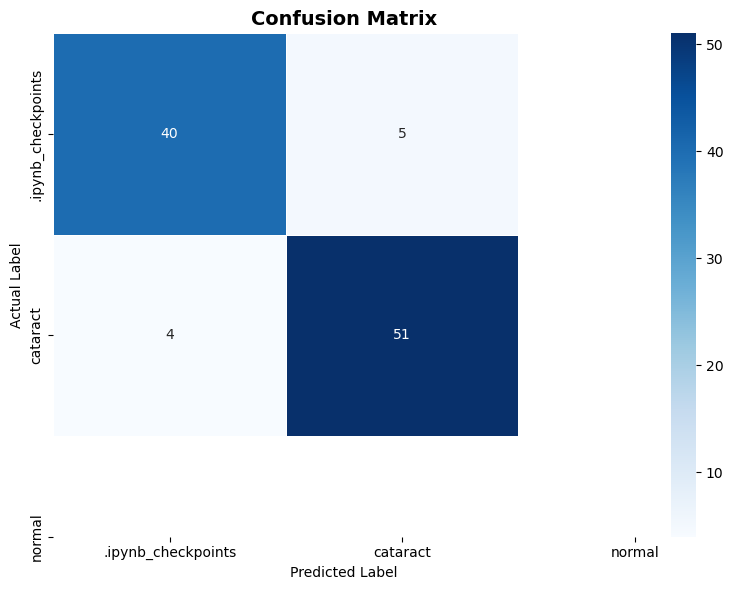

✅ Confusion matrix saved!


In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5
)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('✅ Confusion matrix saved!')

## Cell 12 - دالة التشخيص مع درجة الشدة (محدثة)

In [19]:
def get_severity(diagnosis, confidence):
    """
    تحديد درجة شدة المرض بناءً على نسبة الثقة
    - أقل من 40%  → خفيف
    - 40% لـ 70%  → متوسط
    - أكتر من 70% → شديد
    """
    if diagnosis == 'normal':
        return 'طبيعي ✅', 'green'
    if confidence < 40:
        return 'خفيف 🟡', 'gold'
    elif confidence < 70:
        return 'متوسط 🟠', 'orange'
    else:
        return 'شديد 🔴', 'red'


def predict_eye_disease(image_path, model, class_names, img_size=224):
    """
    تشخيص مرض العين من صورة مع درجة الشدة
    """
    # قراءة وتجهيز الصورة
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (img_size, img_size))
    img_normalized = img_resized / 255.0
    img_expanded = np.expand_dims(img_normalized, axis=0)

    # التنبؤ
    preds = model.predict(img_expanded, verbose=0)
    predicted_idx = np.argmax(preds[0])
    confidence = preds[0][predicted_idx] * 100
    diagnosis = class_names[predicted_idx]

    # درجة الشدة
    severity, color = get_severity(diagnosis, confidence)

    # عرض النتيجة
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].imshow(img)
    axes[0].set_title('الصورة المدخلة', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    bar_colors = [color if c == diagnosis else 'lightgray' for c in class_names]
    bars = axes[1].barh(
        class_names,
        [p * 100 for p in preds[0]],
        color=bar_colors,
        edgecolor='black',
        linewidth=0.5
    )
    axes[1].set_xlim(0, 110)
    axes[1].set_xlabel('نسبة الثقة (%)', fontsize=11)
    axes[1].set_title('نتيجة التشخيص', fontsize=12, fontweight='bold')
    for bar, val in zip(bars, preds[0]):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f'{val*100:.1f}%', va='center', fontsize=11, fontweight='bold')

    diagnosis_ar = 'مياه بيضاء (Cataract)' if diagnosis == 'cataract' else 'طبيعي (Normal)'
    plt.suptitle(
        f'التشخيص: {diagnosis_ar}\n'
        f'نسبة الإصابة: {confidence:.1f}%  |  الشدة: {severity}',
        fontsize=13, fontweight='bold', color=color
    )
    plt.tight_layout()
    plt.show()

    print(f'\n📋 ملخص النتيجة:')
    print(f'   التشخيص  : {diagnosis_ar}')
    print(f'   الثقة    : {confidence:.1f}%')
    print(f'   الشدة    : {severity}')

    return diagnosis, confidence, severity


print('✅ دالة التشخيص جاهزة مع درجة الشدة!')

✅ دالة التشخيص جاهزة مع درجة الشدة!


## Cell 13 - تصوير من الكاميرا مباشرة والتشخيص

In [ ]:
def capture_and_predict(model, class_names, save_path='captured_eye.jpg', img_size=224):
    """
    فتح الكاميرا، التقاط صورة، وتشخيصها مباشرة
    اضغط SPACE لالتقاط الصورة
    اضغط ESC للخروج بدون تصوير
    """
    print('📷 جاري فتح الكاميرا...')
    print('   اضغط SPACE لالتقاط الصورة')
    print('   اضغط ESC للخروج بدون تصوير')

    cap = cv2.VideoCapture(2)

    if not cap.isOpened():
        print('❌ مش قادر يفتح الكاميرا! تأكد إنها متوصلة.')
        return

    captured = False
    frame_to_save = None

    while True:
        ret, frame = cap.read()
        if not ret:
            print('❌ مشكلة في قراءة الكاميرا!')
            break

        # رسم دائرة إرشادية لتحديد مكان العين
        h, w = frame.shape[:2]
        cx, cy = w // 2, h // 2
        cv2.circle(frame, (cx, cy), 120, (0, 255, 0), 2)
        cv2.putText(frame, 'Center your eye in the circle',
                   (cx - 160, cy - 140),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        cv2.putText(frame, 'SPACE = Capture  |  ESC = Exit',
                   (10, h - 15),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)

        cv2.imshow('Eye Camera', frame)

        key = cv2.waitKey(1) & 0xFF
        if key == 32:  # SPACE
            frame_to_save = frame.copy()
            captured = True
            print('📸 تم التقاط الصورة!')
            break
        elif key == 27:  # ESC
            print('❌ تم الإلغاء.')
            break

    cap.release()
    cv2.destroyAllWindows()

    if captured and frame_to_save is not None:
        cv2.imwrite(save_path, frame_to_save)
        print(f'💾 الصورة محفوظة في: {save_path}')
        print('\n🔍 جاري التشخيص...')
        return predict_eye_disease(save_path, model, class_names, img_size)
    else:
        print('لم يتم التقاط أي صورة.')
        return None


# ✅ شغل الكاميرا مباشرة
capture_and_predict(model, CLASS_NAMES)

📷 جاري فتح الكاميرا...
   اضغط SPACE لالتقاط الصورة
   اضغط ESC للخروج بدون تصوير
❌ تم الإلغاء.


## Cell 14 - حفظ الموديل النهائي

In [ ]:
# حفظ الموديل
model.save('eye_disease_model_final.h5')
print('✅ Model saved as: eye_disease_model_final.h5')

# حفظ أسماء الكلاسات
import json
with open('class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)
print('✅ Class names saved as: class_names.json')

print('\n📦 Files saved:')
print('   - eye_disease_model_final.h5  (الموديل النهائي)')
print('   - best_eye_model.h5           (أحسن موديل أثناء التدريب)')
print('   - class_names.json            (أسماء الكلاسات)')
print('   - training_history.png        (منحنيات التدريب)')
print('   - confusion_matrix.png        (مصفوفة الارتباك)')

## Cell 15 - تحميل الموديل المحفوظ واستخدامه

In [ ]:
# لو عايز تحمل الموديل في وقت تاني
from tensorflow.keras.models import load_model

# تحميل الموديل
loaded_model = load_model('eye_disease_model_final.h5')

# تحميل أسماء الكلاسات
with open('class_names.json', 'r') as f:
    loaded_class_names = json.load(f)

print('✅ Model loaded successfully!')
print(f'   Classes: {loaded_class_names}')

# استخدامه في التنبؤ
# diagnosis, conf = predict_eye_disease('path/to/image.jpg', loaded_model, loaded_class_names)